#AAI-511 Group 6 Final Project

Juan Norena  
Evelin Bustamante  
Daniel Sims

## 1. Data Collection & Setup

In [1]:
!pip install pretty_midi pypianoroll -q
print("Libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00
Libraries installed successfully.


### Downloading the Dataset

In [3]:
!pip install kagglehub -q
import kagglehub
import shutil
import os

DATA_DIR = 'music_data'

# Check if directory exists and is not empty
# if os.path.exists(DATA_DIR) and len(os.listdir(DATA_DIR)) > 0:
#     print(f"'{DATA_DIR}' already exists and contains files. Skipping download.")
# else:

print("Downloading dataset via kagglehub...")
# Download latest version
path = kagglehub.dataset_download("blanderbuss/midi-classic-music")
print("Path to downloaded files:", path)

# Move files to our expected 'music_data' directory for the rest of the notebook
os.makedirs(DATA_DIR, exist_ok=True)
for item in os.listdir(path):
    s = os.path.join(path, item)
    d = os.path.join(DATA_DIR, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print(f"Dataset successfully copied to /{DATA_DIR}/")

100%|██████████| 68.2M/68.2M [00:03<00:00, 22.2MB/s]

Extracting files...


Path to downloaded files: /root/.cache/kagglehub/datasets/blanderbuss/midi-classic-music/versions/1
Dataset successfully copied to /music_data/


## 2. Data Pre-processing and Feature Extraction

In [5]:
import glob
import pretty_midi
import pandas as pd
import numpy as np
import collections
from tqdm import tqdm

# Define our target composers
TARGET_COMPOSERS = ['bach', 'beethoven', 'chopin', 'mozart']
DATA_PATH = 'music_data/'

def get_midi_files(data_path, target_composers):
    """
    Scans the directory for MIDI files matching the target composers.
    Assumes file names or folder names contain the composer's name.
    """
    all_midi_files = glob.glob(os.path.join(data_path, '**/*.mid*'), recursive=True)
    filtered_files = []

    for file in all_midi_files:
        file_lower = file.lower()
        for composer in target_composers:
            if composer in file_lower:
                filtered_files.append({'path': file, 'composer': composer})
                break # Move to next file once composer is found

    return pd.DataFrame(filtered_files)

df_files = get_midi_files(DATA_PATH, TARGET_COMPOSERS)
print(f"Found {len(df_files)} MIDI files matching target composers.")
if not df_files.empty:
    display(df_files['composer'].value_counts())

Found 1559 MIDI files matching target composers.


,count
composer,
bach,950
mozart,259
beethoven,212
chopin,138


### Extracting Notes from MIDI

In [7]:
def midi_to_notes(midi_file: str) -> pd.DataFrame:
    """
    Extracts notes from a MIDI file and returns a DataFrame of note attributes.
    """
    try:
        pm = pretty_midi.PrettyMIDI(midi_file)
    except Exception as e:
        # Some MIDI files might be corrupted or unreadable
        # print(f"Error reading {midi_file}: {e}")
        return None

    instrument = pm.instruments[0] # Usually the main instrument (e.g., Piano)
    notes = collections.defaultdict(list)

    # Sort the notes by start time
    sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
    prev_start = sorted_notes[0].start if sorted_notes else 0

    for note in sorted_notes:
        start = note.start
        end = note.end
        notes['pitch'].append(note.pitch)
        notes['velocity'].append(note.velocity) # Added velocity feature
        notes['start'].append(start)
        notes['end'].append(end)
        notes['step'].append(start - prev_start)
        notes['duration'].append(end - start)
        prev_start = start

    return pd.DataFrame({name: np.array(value) for name, value in notes.items()})

if not df_files.empty:
    sample_file = df_files.iloc[0]['path']
    sample_notes = midi_to_notes(sample_file)
    if sample_notes is not None:
        display(sample_notes.head())

,pitch,velocity,start,end,step,duration
0,51,88,0.007143,0.150000,0.000000,0.142857
1,48,92,0.125000,0.217857,0.117857,0.092857
2,51,81,0.232143,0.339285,0.107143,0.107143
3,55,82,0.346428,0.478571,0.114286,0.132143
4,60,84,0.446428,0.553571,0.100000,0.107143


## 3. Data Preparation for Model Training

Once notes are extracted, they need to be normalized and chunked into fixed-length sequences (e.g., sequences of 50 or 100 notes) so they can be fed into an LSTM or CNN. The code below provides the skeleton for building these sequence datasets.

In [ ]:
def create_sequences(df_files, seq_length=100):
    """
    Processes all MIDI files to create numerical sequences and labels.
    """
    all_sequences = []
    all_labels = []

    # Mapping composers to integers
    label_map = {comp: idx for idx, comp in enumerate(TARGET_COMPOSERS)}

    print("Processing MIDI files into sequences...")
    for idx, row in tqdm(df_files.iterrows(), total=len(df_files)):
        notes_df = midi_to_notes(row['path'])
        if notes_df is None or len(notes_df) < seq_length:
            continue

        # Extract relevant features including the new velocity feature
        features = notes_df[['pitch', 'step', 'duration', 'velocity']].values
        label = label_map[row['composer']]

        # Create overlapping sequences
        for i in range(0, len(features) - seq_length, seq_length):
            seq = features[i:i + seq_length]
            all_sequences.append(seq)
            all_labels.append(label)

    return np.array(all_sequences), np.array(all_labels)

X, y = create_sequences(df_files, seq_length=100)
print(f"\nCreated {X.shape[0]} sequences of length {X.shape[1]}.")
print(f"Feature shape per note: {X.shape[2]} (pitch, step, duration, velocity)")

Processing MIDI files into sequences...


  0%|          | 3/1559 [00:00<02:25, 10.72it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
  0%|          | 6/1559 [00:00<01:50, 14.09it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
  1%|          | 12/1559 [00:03<09:36,  2.68it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pr


Created 11241 sequences of length 100.
Feature shape per note: 4 (pitch, step, duration, velocity)


## 4. Exploratory Data Analysis (EDA)

/tmp/ipykernel_1413/988499045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_files, x='composer', order=TARGET_COMPOSERS, palette='viridis')


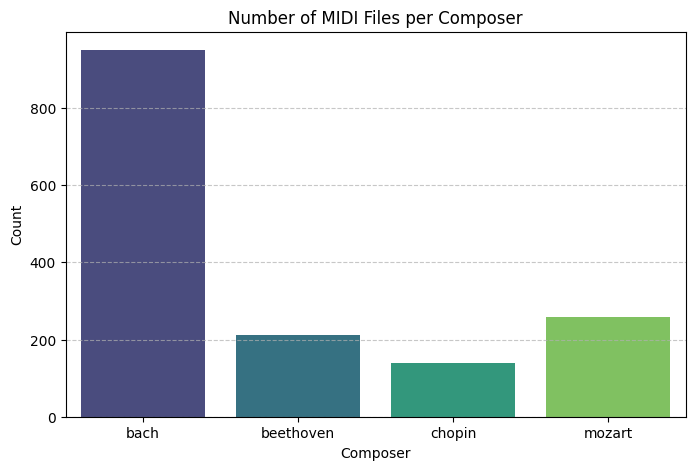

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Composer Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_files, x='composer', order=TARGET_COMPOSERS, palette='viridis')
plt.title('Number of MIDI Files per Composer')
plt.xlabel('Composer')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

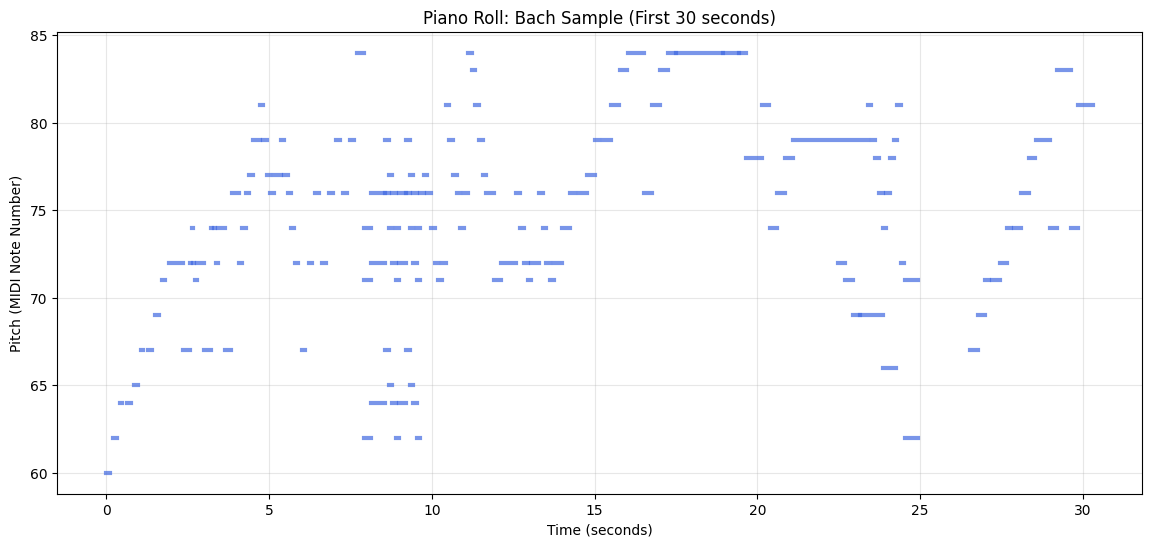

In [ ]:
def plot_piano_roll(notes_df, title="Piano Roll", end_time=None):
    """
    Plots a piano roll (pitch over time) for a given DataFrame of notes.
    """
    plt.figure(figsize=(14, 6))

    if end_time:
        notes_df = notes_df[notes_df['start'] < end_time]

    for _, note in notes_df.iterrows():

        plt.plot([note['start'], note['end']], [note['pitch'], note['pitch']],
                 linewidth=3, color='royalblue', alpha=0.7)

    plt.title(title)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Pitch (MIDI Note Number)')
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot the first 30 seconds of the sample file
if not df_files.empty and sample_notes is not None:
    composer_name = df_files.iloc[0]['composer'].title()
    plot_piano_roll(sample_notes, title=f"Piano Roll: {composer_name} Sample (First 30 seconds)", end_time=30.0)

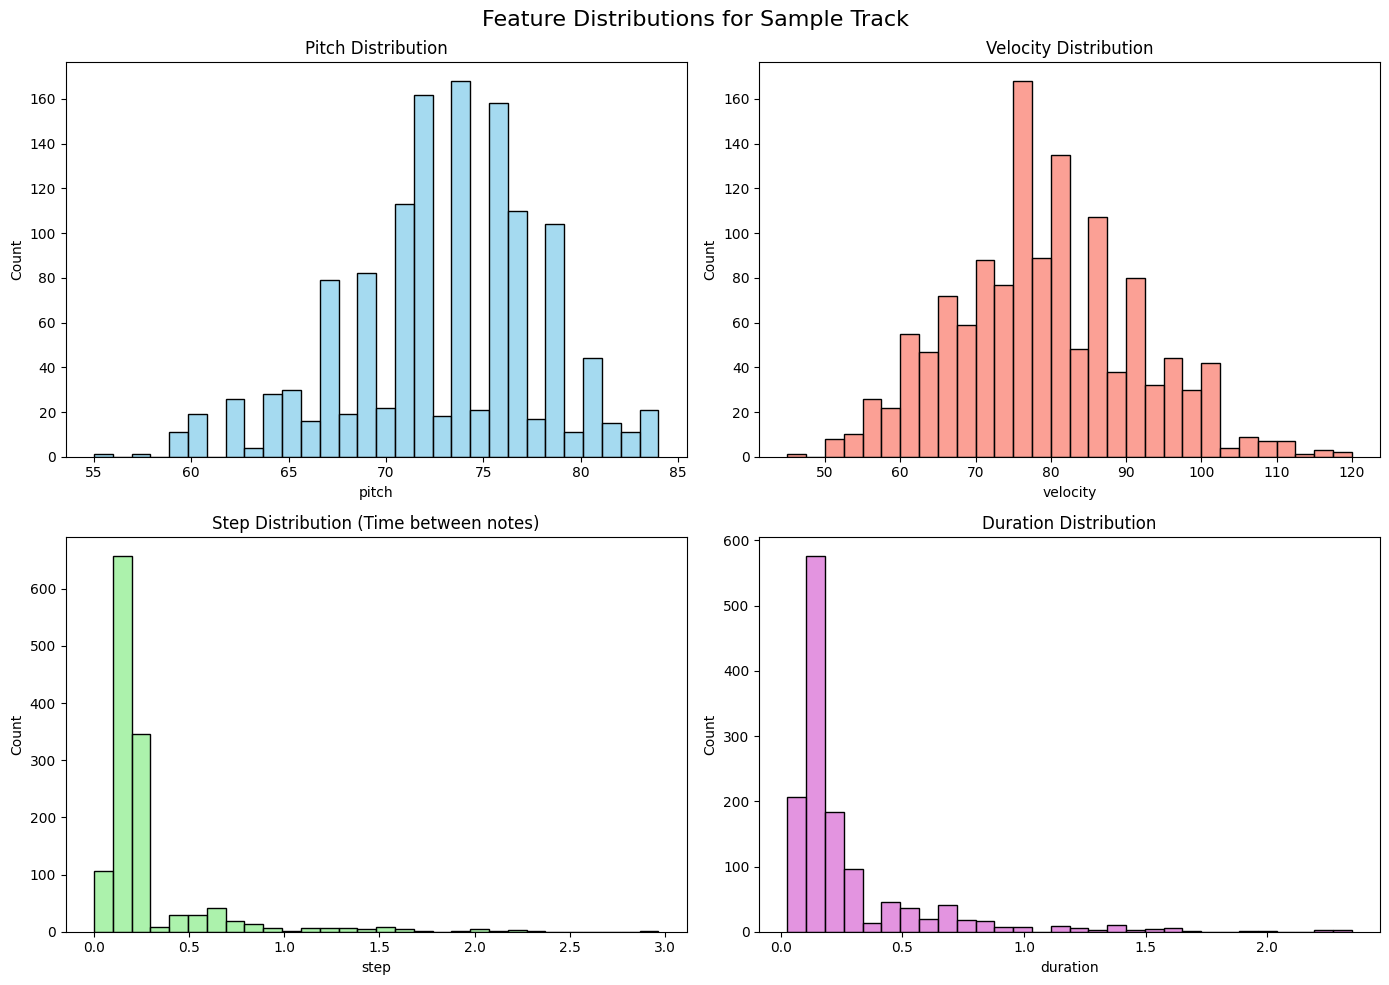

In [ ]:
# Feature Distributions
if not df_files.empty and sample_notes is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Feature Distributions for Sample Track', fontsize=16)

    sns.histplot(sample_notes['pitch'], bins=30, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Pitch Distribution')

    sns.histplot(sample_notes['velocity'], bins=30, ax=axes[0, 1], color='salmon')
    axes[0, 1].set_title('Velocity Distribution')

    sns.histplot(sample_notes['step'], bins=30, ax=axes[1, 0], color='lightgreen')
    axes[1, 0].set_title('Step Distribution (Time between notes)')

    sns.histplot(sample_notes['duration'], bins=30, ax=axes[1, 1], color='orchid')
    axes[1, 1].set_title('Duration Distribution')

    plt.tight_layout()
    plt.show()

In [ ]:
import pretty_midi
import numpy as np
import pandas as pd
import collections
from tqdm import tqdm

#to get back the notes and the full files

def analyze_midi_file(midi_file):
    """
    Parses a MIDI file once, returning (notes_df, file_meta_dict).
    Returns (None, None) if the file is corrupted/unreadable.
    """
    try:
        pm = pretty_midi.PrettyMIDI(midi_file)
    except Exception:
        return None, None

    if not pm.instruments:
        return None, None

    instrument = pm.instruments[0]
    if len(instrument.notes) == 0:
        return None, None

    sorted_notes = sorted(instrument.notes, key=lambda n: n.start)
    notes = collections.defaultdict(list)
    prev_start = sorted_notes[0].start

    for note in sorted_notes:
        start, end = note.start, note.end
        notes['pitch'].append(note.pitch)
        notes['velocity'].append(note.velocity)
        notes['start'].append(start)
        notes['end'].append(end)
        notes['step'].append(start - prev_start)
        notes['duration'].append(end - start)
        prev_start = start

    notes_df = pd.DataFrame(notes)

    # File-level metadata
    _, tempo_values = pm.get_tempo_changes()
    avg_tempo = float(np.mean(tempo_values)) if len(tempo_values) > 0 else np.nan

    # Polyphony: how many notes sound simultaneously (sampled at 10Hz)
    piano_roll = instrument.get_piano_roll(fs=10)
    active_notes = (piano_roll > 0).sum(axis=0)
    sounding = active_notes[active_notes > 0]
    avg_polyphony = float(sounding.mean()) if len(sounding) > 0 else 0.0
    max_polyphony = int(active_notes.max())

    file_meta = {
        'duration_sec': pm.get_end_time(),
        'num_notes': len(notes_df),
        'avg_tempo': avg_tempo,
        'avg_polyphony': avg_polyphony,
        'max_polyphony': max_polyphony,
        'num_instruments': len(pm.instruments),
    }

    return notes_df, file_meta

In [ ]:
SAMPLE_PER_COMPOSER = None

df_to_process = df_files
if SAMPLE_PER_COMPOSER:
    df_to_process = (
        df_files.groupby('composer', group_keys=False)
        .apply(lambda x: x.sample(min(len(x), SAMPLE_PER_COMPOSER), random_state=42))
    )

all_notes = []
file_meta_records = []
parse_attempts = collections.Counter()
parse_failures = collections.Counter()

for idx, row in tqdm(df_to_process.iterrows(), total=len(df_to_process)):
    composer = row['composer']
    parse_attempts[composer] += 1

    notes_df, file_meta = analyze_midi_file(row['path'])

    if notes_df is None:
        parse_failures[composer] += 1
        continue

    notes_df['composer'] = composer
    notes_df['file_path'] = row['path']
    all_notes.append(notes_df)

    file_meta['composer'] = composer
    file_meta['file_path'] = row['path']
    file_meta_records.append(file_meta)

all_notes_df = pd.concat(all_notes, ignore_index=True)
file_meta_df = pd.DataFrame(file_meta_records)

print(f"Parsed {len(all_notes_df)} total notes across {len(file_meta_df)} files.")

  0%|          | 3/1559 [00:00<03:40,  7.07it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
  0%|          | 5/1559 [00:00<02:37,  9.86it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
  1%|          | 12/1559 [00:02<05:56,  4.33it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pr

Parsed 1203825 total notes across 1556 files.


In [ ]:
parse_summary = pd.DataFrame({
    'attempted': parse_attempts,
    'failed': parse_failures
}).fillna(0).astype(int)
parse_summary['succeeded'] = parse_summary['attempted'] - parse_summary['failed']
parse_summary['success_rate_%'] = (parse_summary['succeeded'] / parse_summary['attempted'] * 100).round(1)
display(parse_summary)

,attempted,failed,succeeded,success_rate_%
bach,950,0,950,100.0
chopin,138,1,137,99.3
mozart,259,1,258,99.6
beethoven,212,1,211,99.5


/tmp/ipykernel_1413/125342089.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_notes_df, x='composer', y='pitch', order=TARGET_COMPOSERS, ax=axes[0,0], palette='viridis')
/tmp/ipykernel_1413/125342089.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_notes_df, x='composer', y='velocity', order=TARGET_COMPOSERS, ax=axes[0,1], palette='viridis')
/tmp/ipykernel_1413/125342089.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_notes_df, x='composer', y='step', order=TARGET_COMPOSERS, ax=axes[1,0], palette='virid

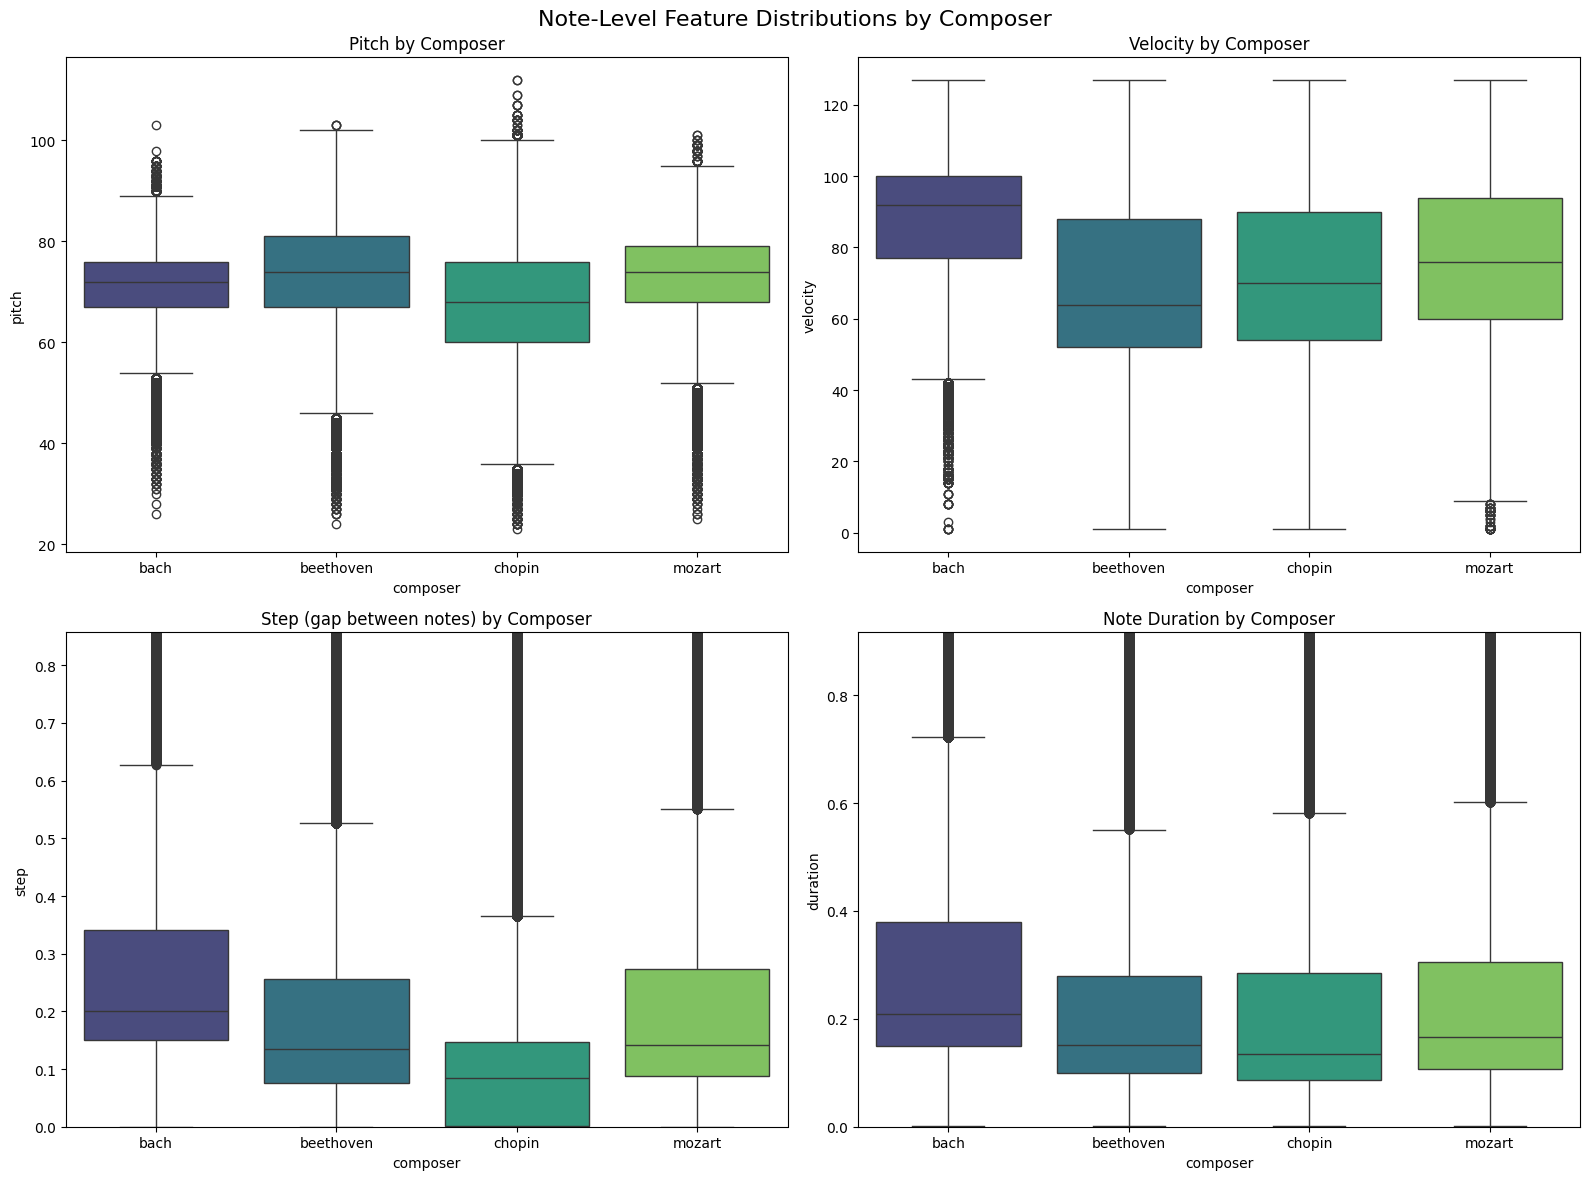

In [ ]:
#Note Level by Composer
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Note-Level Feature Distributions by Composer', fontsize=16)

sns.boxplot(data=all_notes_df, x='composer', y='pitch', order=TARGET_COMPOSERS, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Pitch by Composer')

sns.boxplot(data=all_notes_df, x='composer', y='velocity', order=TARGET_COMPOSERS, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Velocity by Composer')

sns.boxplot(data=all_notes_df, x='composer', y='step', order=TARGET_COMPOSERS, ax=axes[1,0], palette='viridis')
axes[1,0].set_ylim(0, all_notes_df['step'].quantile(0.95))  # clip extreme outliers for readability
axes[1,0].set_title('Step (gap between notes) by Composer')

sns.boxplot(data=all_notes_df, x='composer', y='duration', order=TARGET_COMPOSERS, ax=axes[1,1], palette='viridis')
axes[1,1].set_ylim(0, all_notes_df['duration'].quantile(0.95))
axes[1,1].set_title('Note Duration by Composer')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1413/2382693481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=file_meta_df, x='composer', y='duration_sec', order=TARGET_COMPOSERS, palette='magma')


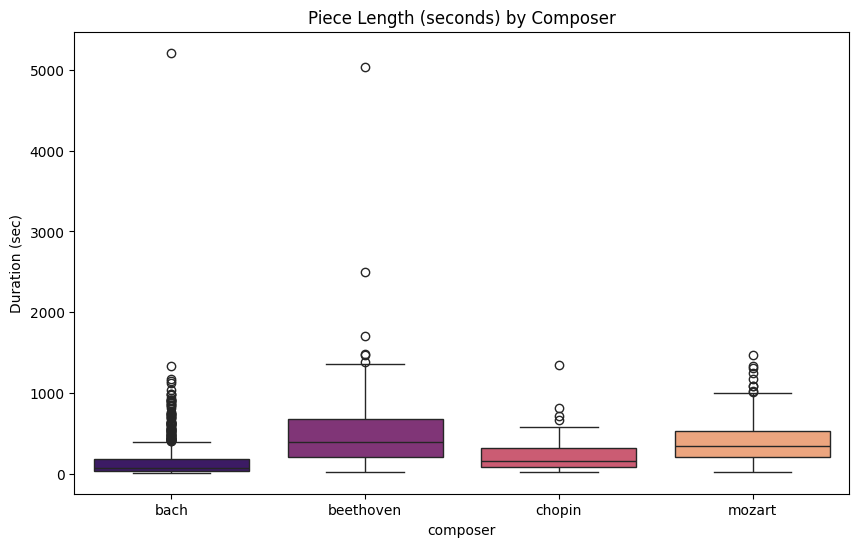

,count,mean,std,min,25%,50%,75%,max
composer,,,,,,,,
bach,950.0,152.147854,247.878217,17.500000,40.827270,69.913768,184.865297,5209.310787
beethoven,211.0,508.257079,493.642193,21.868678,208.626734,393.088039,676.102653,5032.305478
chopin,137.0,221.642817,184.064054,23.305820,92.727350,159.629232,317.049392,1352.741667
mozart,258.0,402.274973,274.085360,26.098847,207.966467,347.826371,530.106956,1478.134309


In [ ]:
#Piece Length by Composer
plt.figure(figsize=(10, 6))
sns.boxplot(data=file_meta_df, x='composer', y='duration_sec', order=TARGET_COMPOSERS, palette='magma')
plt.title('Piece Length (seconds) by Composer')
plt.ylabel('Duration (sec)')
plt.show()

display(file_meta_df.groupby('composer')['duration_sec'].describe())

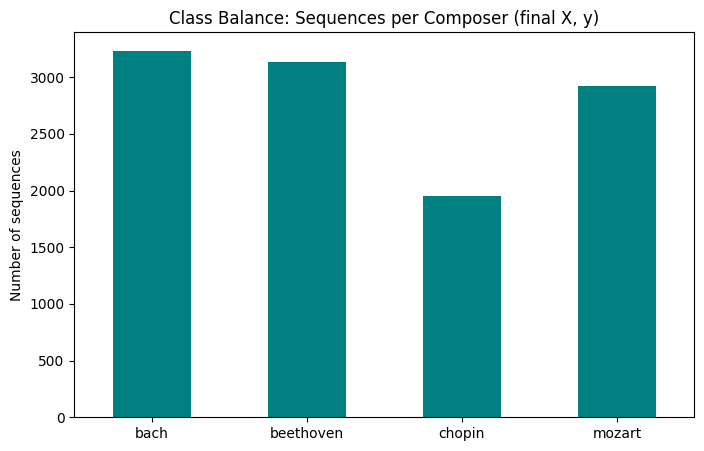

Sequence counts per composer:
bach         3234
beethoven    3130
chopin       1956
mozart       2921
dtype: int64

Imbalance ratio (max/min): 1.65


In [ ]:
#Class Balance
label_map = {comp: idx for idx, comp in enumerate(TARGET_COMPOSERS)}
inv_label_map = {v: k for k, v in label_map.items()}

unique, counts = np.unique(y, return_counts=True)
seq_counts = pd.Series({inv_label_map[u]: c for u, c in zip(unique, counts)}).reindex(TARGET_COMPOSERS)

plt.figure(figsize=(8, 5))
seq_counts.plot(kind='bar', color='teal')
plt.title('Class Balance: Sequences per Composer (final X, y)')
plt.ylabel('Number of sequences')
plt.xticks(rotation=0)
plt.show()

print("Sequence counts per composer:")
print(seq_counts)
print(f"\nImbalance ratio (max/min): {seq_counts.max() / seq_counts.min():.2f}")

In [ ]:
#Pitch Range by Composer
tessitura = all_notes_df.groupby('composer')['pitch'].agg(
    min_pitch='min', max_pitch='max', mean_pitch='mean', std_pitch='std',
    q25_pitch=lambda x: x.quantile(0.25),
    q75_pitch=lambda x: x.quantile(0.75)
)
tessitura['range'] = tessitura['max_pitch'] - tessitura['min_pitch']
tessitura['iqr'] = tessitura['q75_pitch'] - tessitura['q25_pitch']
display(tessitura)

,min_pitch,max_pitch,mean_pitch,std_pitch,q25_pitch,q75_pitch,range,iqr
composer,,,,,,,,
bach,26,103,70.823552,7.202578,67.0,76.0,77,9.0
beethoven,24,103,72.841889,11.156741,67.0,81.0,79,14.0
chopin,23,112,67.655189,12.636339,60.0,76.0,89,16.0
mozart,25,101,72.694923,8.898793,68.0,79.0,76,11.0


### **Feature Extraction Continued**

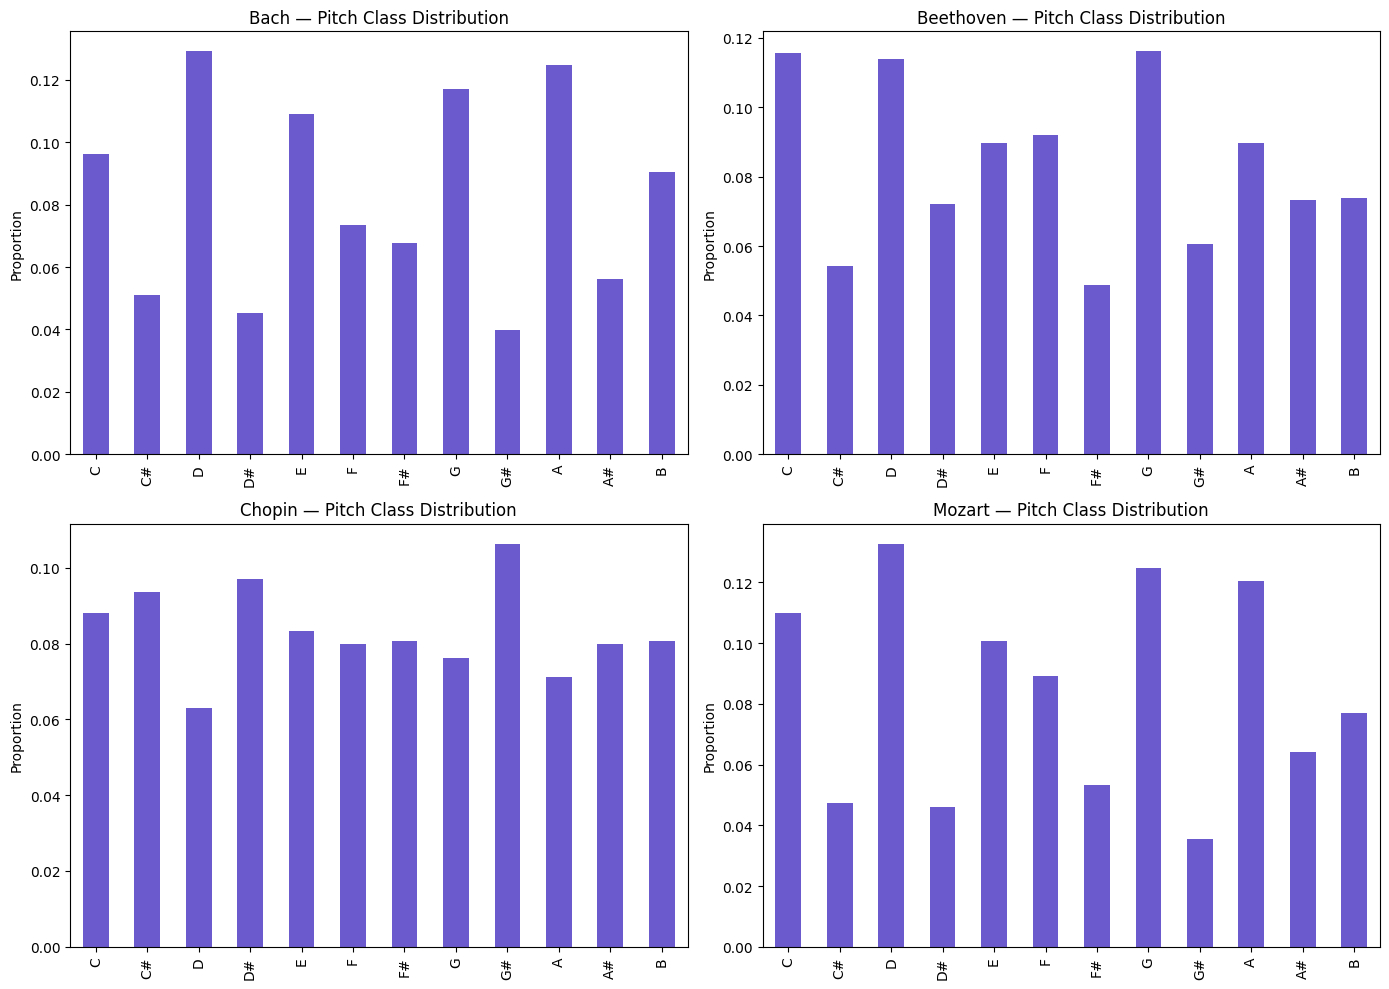

In [ ]:
all_notes_df['pitch_class'] = all_notes_df['pitch'] % 12
pitch_class_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

pitch_class_dist = (
    all_notes_df.groupby('composer')['pitch_class']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=range(12))
)
pitch_class_dist.columns = pitch_class_names

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, composer in enumerate(TARGET_COMPOSERS):
    if composer in pitch_class_dist.index:
        pitch_class_dist.loc[composer].plot(kind='bar', ax=axes[i], color='slateblue')
        axes[i].set_title(f'{composer.title()} — Pitch Class Distribution')
        axes[i].set_ylabel('Proportion')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1413/412625012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=file_meta_df, x='composer', y='avg_tempo', order=TARGET_COMPOSERS, palette='coolwarm')


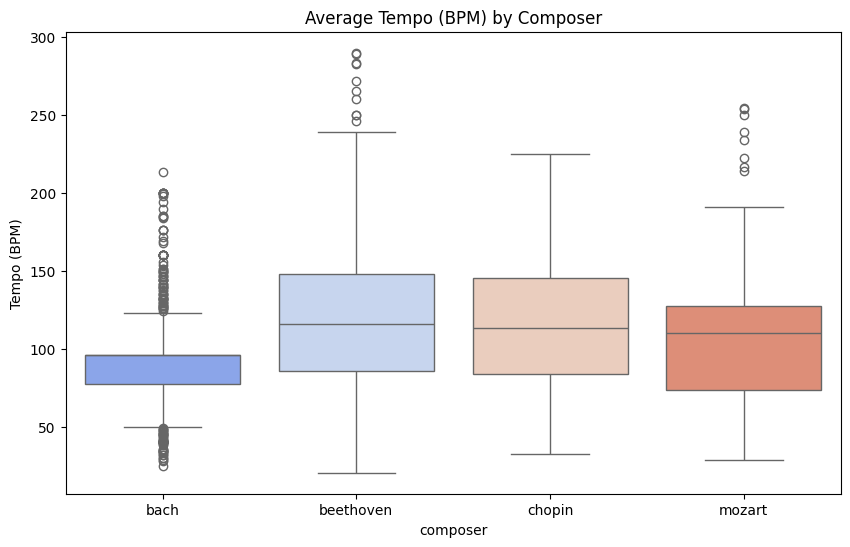

,count,mean,std,min,25%,50%,75%,max
composer,,,,,,,,
bach,950.0,91.160195,26.848845,25.000000,77.458335,96.000000,96.000000,213.166553
beethoven,211.0,120.854841,53.701402,20.563971,85.560654,116.148390,148.247282,289.999859
chopin,137.0,114.703436,41.658966,32.303570,83.761236,113.574476,145.449999,224.792205
mozart,258.0,105.926740,41.741638,28.666671,73.653843,109.999950,127.359788,254.468237


In [ ]:
#Tempo by Composer
plt.figure(figsize=(10, 6))
sns.boxplot(data=file_meta_df, x='composer', y='avg_tempo', order=TARGET_COMPOSERS, palette='coolwarm')
plt.title('Average Tempo (BPM) by Composer')
plt.ylabel('Tempo (BPM)')
plt.show()

display(file_meta_df.groupby('composer')['avg_tempo'].describe())

95.1% of parsed files have more than 1 instrument track.


,count,mean,std,min,25%,50%,75%,max
composer,,,,,,,,
bach,950.0,4.944211,3.342740,1.0,4.0,4.0,5.0,37.0
beethoven,211.0,7.000000,7.242730,1.0,2.0,4.0,13.0,40.0
chopin,137.0,2.437956,3.041046,1.0,1.0,2.0,2.0,20.0
mozart,258.0,7.348837,5.053259,1.0,2.0,7.0,11.0,20.0


/tmp/ipykernel_1413/1034696596.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=file_meta_df, x='composer', y='avg_polyphony', order=TARGET_COMPOSERS, ax=axes[0], palette='cubehelix')
/tmp/ipykernel_1413/1034696596.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=file_meta_df, x='composer', y='max_polyphony', order=TARGET_COMPOSERS, ax=axes[1], palette='cubehelix')


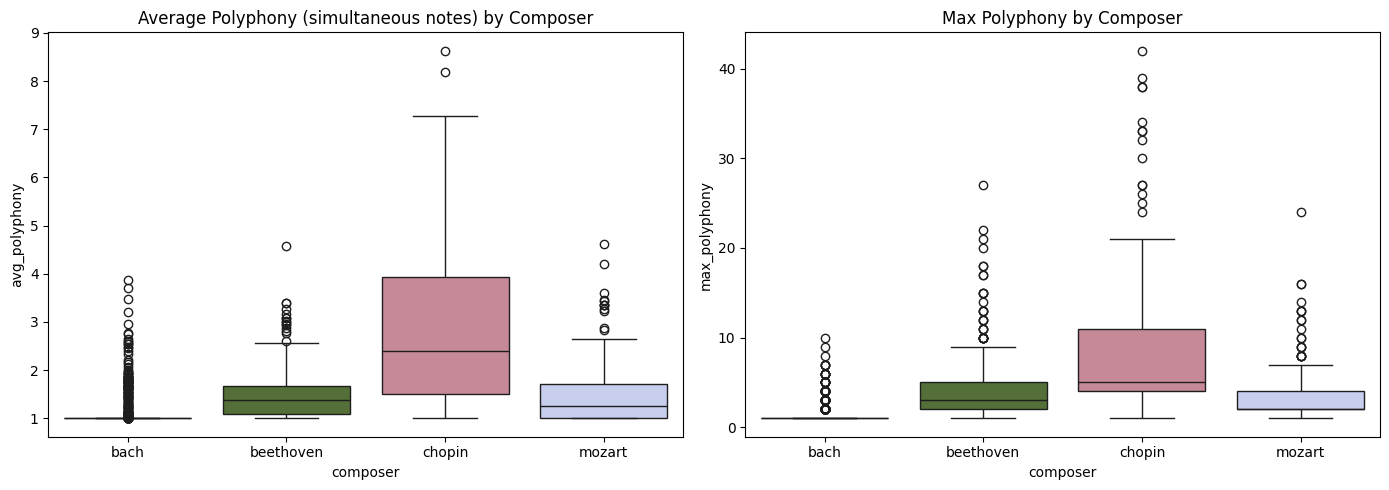

In [ ]:
#Chord density
multi_instrument_pct = (file_meta_df['num_instruments'] > 1).mean() * 100
print(f"{multi_instrument_pct:.1f}% of parsed files have more than 1 instrument track.")
display(file_meta_df.groupby('composer')['num_instruments'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=file_meta_df, x='composer', y='avg_polyphony', order=TARGET_COMPOSERS, ax=axes[0], palette='cubehelix')
axes[0].set_title('Average Polyphony (simultaneous notes) by Composer')

sns.boxplot(data=file_meta_df, x='composer', y='max_polyphony', order=TARGET_COMPOSERS, ax=axes[1], palette='cubehelix')
axes[1].set_title('Max Polyphony by Composer')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1413/1769396811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_notes_df, x='composer', y='pitch_interval', order=TARGET_COMPOSERS, palette='Spectral')


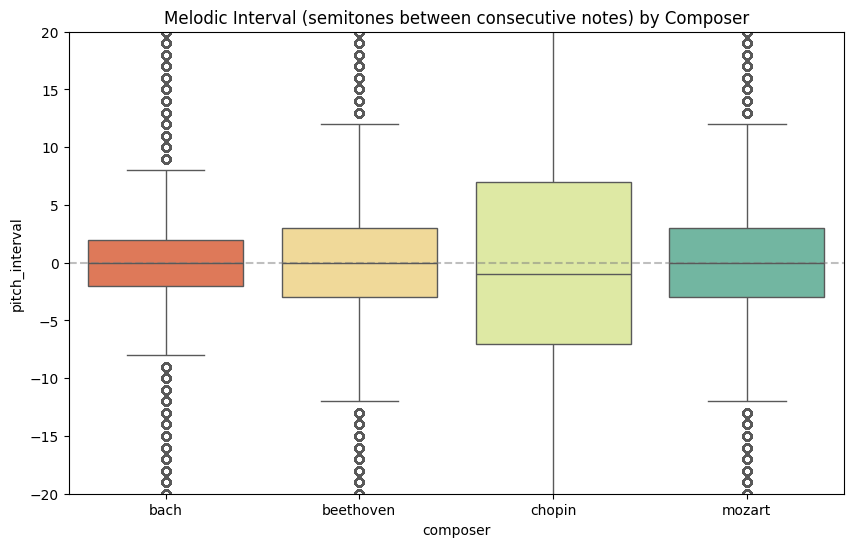

,mean_interval,std_interval,mean_abs_interval
composer,,,
bach,-0.004506,5.390751,3.693471
beethoven,-0.000365,8.762509,5.711082
chopin,-0.001596,13.109138,9.613760
mozart,-0.000410,6.796033,4.549934


In [ ]:
#Pitch movement between notes
all_notes_df['pitch_interval'] = all_notes_df.groupby('file_path')['pitch'].diff()

plt.figure(figsize=(10, 6))
sns.boxplot(data=all_notes_df, x='composer', y='pitch_interval', order=TARGET_COMPOSERS, palette='Spectral')
plt.ylim(all_notes_df['pitch_interval'].quantile(0.02), all_notes_df['pitch_interval'].quantile(0.98))
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Melodic Interval (semitones between consecutive notes) by Composer')
plt.show()

interval_stats = all_notes_df.groupby('composer')['pitch_interval'].agg(
    mean_interval='mean', std_interval='std', mean_abs_interval=lambda x: x.abs().mean()
)
display(interval_stats)

Model Architecture and Training

In [14]:
import argparse
import json
import random
from pathlib import Path

import numpy as np
import pretty_midi
import torch
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import train_test_split
import mido

# Changed to DATA_DIR defined in a previous cell, assuming it points to the downloaded dataset.
DEFAULT_DATA = Path("/Users/j2nm/Desktop/USD/Neural Networks and Deep learning/Final project/Composer_Dataset/NN_midi_files_extended")
NOTEBOOK_COMPOSERS = ("bach", "beethoven", "chopin", "mozart")
FEATURE_NAMES = ("pitch", "step", "duration", "velocity")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def midi_to_note_features(path: Path) -> np.ndarray:
    """Extract the notebook's pitch, step, duration, and velocity features."""
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
    except (mido.midifiles.meta.KeySignatureError, ValueError) as exc: # Catch mido KeySignatureError and general ValueError
        # print(f"Skipping {path.name}: MIDI parsing error: {exc}") # Commented to reduce verbosity
        raise # Re-raise it to be caught by MidiSequenceDataset's general exception handler

    if not midi.instruments:
        return np.empty((0, len(FEATURE_NAMES)), dtype=np.float32)

    # This intentionally mirrors the notebook: only the first/main instrument.
    notes = sorted(midi.instruments[0].notes, key=lambda note: note.start)
    if not notes:
        return np.empty((0, len(FEATURE_NAMES)), dtype=np.float32)

    features = np.empty((len(notes), len(FEATURE_NAMES)), dtype=np.float32)
    previous_start = notes[0].start
    for index, note in enumerate(notes):
        features[index] = (note.pitch, note.start - previous_start,
                           note.end - note.start, note.velocity)
        previous_start = note.start
    return features


def normalise_features(features: np.ndarray) -> np.ndarray:
    """Use stable per-feature scaling while preserving the notebook's features."""
    scaled = features.copy()
    scaled[:, 0] /= 127.0  # pitch
    scaled[:, 1:3] = np.log1p(np.maximum(scaled[:, 1:3], 0.0)) / np.log1p(30.0)
    scaled[:, 3] /= 127.0  # velocity
    return scaled


class MidiSequenceDataset(Dataset[tuple[Tensor, int]]):
    """Notebook-style, non-overlapping fixed-length sequences from each score."""

    def __init__(self, midi_files_and_labels: list[tuple[Path, int]], sequence_length: int) -> None:
        self.samples: list[tuple[Tensor, int]] = []
        self.sequence_length = sequence_length
        skipped = 0
        for path, label in midi_files_and_labels:
            try:
                features = midi_to_note_features(path)
            except (mido.midifiles.meta.KeySignatureError, ValueError, OSError, EOFError) as exc: # Catch mido KeySignatureError, ValueError, OSError, EOFError
                # print(f"Skipping unreadable MIDI {path.name}: {exc}") # Commented to reduce verbosity
                skipped += 1
                continue
            if len(features) < sequence_length:
                # print(f"Skipping MIDI {path.name}: not enough notes for sequence length {sequence_length}") # Commented to reduce verbosity
                skipped += 1
                continue
            # Same chunk boundaries as create_sequences(..., seq_length=100).
            for start in range(0, len(features) - sequence_length + 1, sequence_length):
                sequence = normalise_features(features[start:start + sequence_length])
                self.samples.append((torch.from_numpy(sequence.T.copy()), label))
        if not self.samples:
            raise ValueError(f"No valid {sequence_length}-note sequences found for the provided files.")
        if skipped:
            print(f"Skipped {skipped} unreadable or too short MIDI files from this dataset split.")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> tuple[Tensor, int]:
        return self.samples[index]


class CNNClassifier(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=7, padding=3), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2), nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.35), nn.Linear(256, num_classes))

    def forward(self, sequence: Tensor) -> Tensor:
        return self.classifier(self.features(sequence))


class LSTMClassifier(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.lstm = nn.LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.25)
        self.classifier = nn.Sequential(nn.Dropout(0.35), nn.Linear(128, num_classes))

    def forward(self, sequence: Tensor) -> Tensor:
        _, (hidden, _) = self.lstm(sequence.transpose(1, 2))
        return self.classifier(hidden[-1])

def make_loaders(args: argparse.Namespace) -> tuple[dict[str, DataLoader], dict[str, int]]:
    # Retrieve the df_files DataFrame from the global scope (created in previous cells)
    if 'df_files' not in globals():
        raise ValueError("df_files DataFrame not found in global scope. Please ensure previous data preparation cells have been run.")
    all_midi_df = globals()['df_files']

    # Filter df_files based on requested composers from command-line arguments
    requested_composers = set(args.composers.split(","))
    filtered_df = all_midi_df[all_midi_df['composer'].isin(requested_composers)].copy()

    if filtered_df.empty:
        raise ValueError(f"No MIDI files found for the requested composers: {', '.join(requested_composers)}. "
                         f"Available composers in data: {', '.join(sorted(all_midi_df['composer'].unique()))}")

    # Get unique composers from the filtered data, and create a mapping
    actual_composers_in_data = sorted(filtered_df['composer'].unique())
    if len(actual_composers_in_data) < 2:
        raise ValueError(f"At least two composers are required for classification, but only {len(actual_composers_in_data)} "
                         f"({''.join(actual_composers_in_data)}) found after filtering.")

    mapping = {name: index for index, name in enumerate(actual_composers_in_data)}
    filtered_df['label'] = filtered_df['composer'].map(mapping)

    # Perform stratified train/dev/test split on the DataFrame
    # Using stratify to ensure composer distribution is maintained across splits
    train_df, test_df = train_test_split(filtered_df, test_size=0.2, stratify=filtered_df['composer'], random_state=args.seed)
    train_df, dev_df = train_test_split(train_df, test_size=0.25, stratify=train_df['composer'], random_state=args.seed) # 0.25 of 0.8 is 0.2 of total (0.8 * 0.25 = 0.2)

    loaders: dict[str, DataLoader] = {}
    splits_data = {
        "train": train_df,
        "dev": dev_df,
        "test": test_df
    }

    for split_name, split_df in splits_data.items():
        if split_df.empty:
            print(f"Warning: {split_name} split is empty. Skipping loader for {split_name}.")
            loaders[split_name] = None # Set to None to handle gracefully downstream
            continue

        # Prepare data for MidiSequenceDataset: list of (Path, label_idx)
        midi_files_and_labels = [(Path(row['path']), row['label']) for _, row in split_df.iterrows()]

        dataset: Dataset = MidiSequenceDataset(midi_files_and_labels, args.sequence_length)
        if args.limit_per_class:
            selected: list[int] = []
            seen = {label: 0 for label in mapping.values()}
            for index, (_, label) in enumerate(dataset.samples):
                if seen[label] < args.limit_per_class:
                    selected.append(index)
                    seen[label] += 1
            dataset = Subset(dataset, selected)
        loaders[split_name] = DataLoader(dataset, batch_size=args.batch_size,
                                        shuffle=(split_name == "train"), num_workers=args.workers)
        print(f"{split_name}: {len(dataset)} sequences (from {len(split_df)} files)") # Added file count
    return loaders, mapping


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[float, float]:
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_total = correct = total = 0
    if loader is None: # Handle case where a loader might be skipped
        return 0.0, 0.0
    for sequence, labels in loader:
        sequence, labels = sequence.to(device), labels.to(device)
        logits = model(sequence)
        loss_total += criterion(logits, labels).item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return loss_total / total, correct / total


def train(args: argparse.Namespace) -> None:
    set_seed(args.seed)
    if args.smoke_test:
        args.epochs, args.limit_per_class, args.workers = 1, 3, 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # The args.data_dir argument is no longer used directly to find composer directories
    # but still needs to be present in argparse. The make_loaders function now directly
    # uses the globally available 'df_files' which contains absolute paths.

    loaders, mapping = make_loaders(args)
    # Check if any necessary loader is None (e.g., if a split was empty)
    if loaders.get('train') is None or loaders.get('dev') is None or loaders.get('test') is None:
        print("Warning: One or more data loaders are empty. Cannot proceed with full training/evaluation.")
        return # Exit train function if critical loaders are missing

    model: nn.Module = CNNClassifier(len(mapping)) if args.model == "cnn" else LSTMClassifier(len(mapping))
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.learning_rate, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    output_dir = Path(args.output_dir) / args.model
    output_dir.mkdir(parents=True, exist_ok=True)
    best_dev = float("inf")

    print(f"Training {args.model.upper()} on {device}; classes: {', '.join(mapping)}")
    for epoch in range(1, args.epochs + 1):
        model.train()
        loss_total = correct = total = 0
        for sequence, labels in loaders["train"]:
            sequence, labels = sequence.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(sequence)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_total += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
        dev_loss, dev_accuracy = evaluate(model, loaders["dev"], device)
        print(f"epoch {epoch:02d}: train_loss={loss_total/total:.4f} train_acc={correct/total:.3f} "
              f"dev_loss={dev_loss:.4f} dev_acc={dev_accuracy:.3f}")
        if dev_loss < best_dev:
            best_dev = dev_loss
            torch.save({"model": args.model, "state_dict": model.state_dict(),
                        "composer_to_idx": mapping, "sequence_length": args.sequence_length,
                        "features": FEATURE_NAMES}, output_dir / "best.pt")

    checkpoint_path = output_dir / "best.pt"
    if not checkpoint_path.exists():
        print(f"Warning: Best model checkpoint not found at {checkpoint_path}. Skipping final evaluation.")
        return

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["state_dict"])
    test_loss, test_accuracy = evaluate(model, loaders["test"], device)
    summary = {"model": args.model, "device": str(device), "best_dev_loss": best_dev,
               "test_loss": test_loss, "test_accuracy": test_accuracy, "classes": mapping,
               "sequence_length": args.sequence_length, "features": FEATURE_NAMES}
    (output_dir / "metrics.json").write_text(json.dumps(summary, indent=2) + "\n")
    print(f"test_loss={test_loss:.4f} test_acc={test_accuracy:.3f}")
    print(f"Saved {output_dir / 'best.pt'} and {output_dir / 'metrics.json'}")


def parse_args(args=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", type=Path, default=DEFAULT_DATA,
                        help="Root directory for MIDI data (though actual paths are taken from df_files).")
    parser.add_argument("--model", choices=("cnn", "lstm"), required=True)
    parser.add_argument("--composers", default=",".join(NOTEBOOK_COMPOSERS),
                        help="Comma-separated labels; notebook default: bach,beethoven,chopin,mozart")
    parser.add_argument("--sequence-length", type=int, default=100)
    parser.add_argument("--epochs", type=int, default=15)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--learning-rate", type=float, default=1e-3)
    parser.add_argument("--workers", type=int, default=0)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--limit-per-class", type=int, default=0)
    parser.add_argument("--smoke-test", action="store_true")
    parser.add_argument("--output-dir", type=Path, default=Path("outputs"))
    return parser.parse_args(args)


LSTM Model

In [15]:
# Quick sanity check first
train(parse_args(args=['--model', 'lstm', '--epochs', '1', '--smoke-test']))

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Skipped 310 unreadable or too short MIDI files from this dataset split.
train: 12 sequences (from 935 files)
Skipped 93 unreadable or too short MIDI files from this dataset split.
dev: 12 sequences (from 312 files)
Skipped 94 unreadable or too short MIDI files from this dataset split.
test: 12 sequences (from 312 files)
Training LSTM on cpu; classes: bach, beethoven, chopin, mozart
epoch 01: train_loss=1.3951 train_acc=0.167 dev_loss=1.3869 dev_acc=0.250
test_loss=1.3864 test_acc=0.250
Saved outputs/lstm/best.pt and outputs/lstm/metrics.json


In [16]:
# Train the LSTM model
train(parse_args(args=['--model', 'lstm', '--epochs', '15']))

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Skipped 310 unreadable or too short MIDI files from this dataset split.
train: 6631 sequences (from 935 files)
Skipped 93 unreadable or too short MIDI files from this dataset split.
dev: 2345 sequences (from 312 files)
Skipped 94 unreadable or too short MIDI files from this dataset split.
test: 2275 sequences (from 312 files)
Training LSTM on cpu; classes: bach, beethoven, chopin, mozart
epoch 01: train_loss=1.3655 train_acc=0.317 dev_loss=1.3809 dev_acc=0.258
epoch 02: train_loss=1.3695 train_acc=0.284 dev_loss=1.3753 dev_acc=0.311
epoch 03: train_loss=1.3631 train_acc=0.311 dev_loss=1.3778 dev_acc=0.268
epoch 04: train_loss=1.3680 train_acc=0.295 dev_loss=1.3871 dev_acc=0.268
epoch 05: train_loss=1.3528 train_acc=0.322 dev_loss=1.2530 dev_acc=0.423
epoch 06: train_loss=1.3291 train_acc=0.343 dev_loss=1.3798 dev_acc=0.268
epoch 07: train_loss=1.3677 train_acc=0.294 dev_loss=1.3848 dev_acc=0.268
epoch 08: train_loss=1.3663 train_acc=0.300 dev_loss=1.3777 dev_acc=0.268
epoch 09: train_l

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Skipped 310 unreadable or too short MIDI files from this dataset split.
train: 6631 sequences (from 935 files)
Skipped 93 unreadable or too short MIDI files from this dataset split.
dev: 2345 sequences (from 312 files)
Skipped 94 unreadable or too short MIDI files from this dataset split.
test: 2275 sequences (from 312 files)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        bach       0.50      0.69      0.58       619
   beethoven       0.42      0.84      0.56       698
      chopin       0.00      0.00      0.00       382
      mozart       0.00      0.00      0.00       576

    accuracy                           0.45      2275
   macro avg       0.23      0.38      0.28      2275
weighted avg       0.26      0.45      0.33      2275



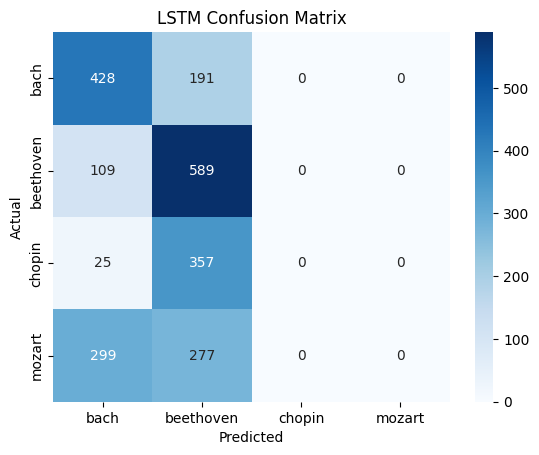

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reload best LSTM checkpoint and rebuild test loader
args = parse_args(args=['--model', 'lstm'])
checkpoint = torch.load('outputs/lstm/best.pt', map_location='cpu', weights_only=False)
mapping = checkpoint['composer_to_idx']
inv_mapping = {v: k for k, v in mapping.items()}

model = LSTMClassifier(len(mapping))
model.load_state_dict(checkpoint['state_dict'])
model.eval()

loaders, _ = make_loaders(args)

all_preds, all_labels = [], []
with torch.no_grad():
    for sequence, labels in loaders['test']:
        logits = model(sequence)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

target_names = [inv_mapping[i] for i in range(len(mapping))]
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM Confusion Matrix')
plt.show()